<a href="https://colab.research.google.com/github/LourdesBranchi/vision-por-computadora-tp1/blob/main/notebooks/GonzalezBranchi-TP1-VPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 1

## Parte 1 - White Patch

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
path = "/content/drive/MyDrive/CEIA - UBA/3B/VPC/TPs/TP1/Material/"

In [14]:
def white_patch(img):
    # Convertir a float para evitar overflow
    img = img.astype(np.float32)

    # Separar canales
    B, G, R = cv2.split(img)

    # Obtener máximos
    R_max = np.max(R)
    G_max = np.max(G)
    B_max = np.max(B)

    # Aplicar corrección
    R_corr = (255 / R_max) * R
    G_corr = (255 / G_max) * G
    B_corr = (255 / B_max) * B

    # Recombinar
    img_corr = cv2.merge([B_corr, G_corr, R_corr])

    # Clip y convertir
    img_corr = np.clip(img_corr, 0, 255).astype(np.uint8)

    return img_corr

Imagen 1


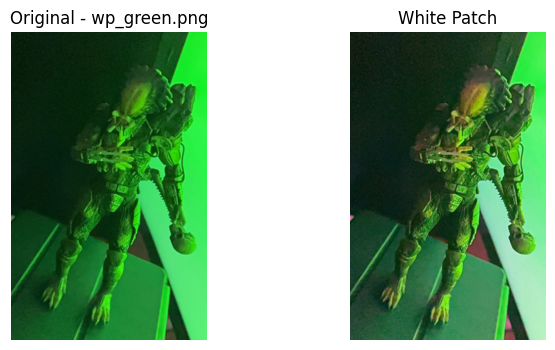

Imagen 2


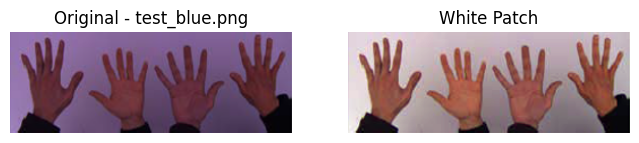

Imagen 3


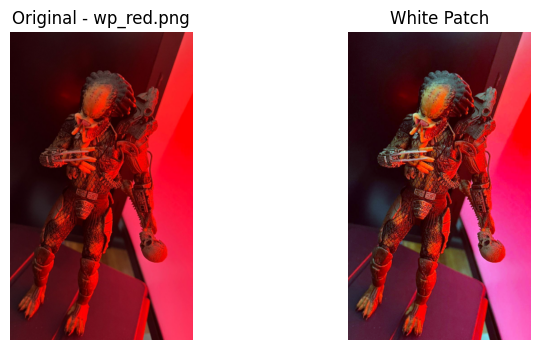

Imagen 4


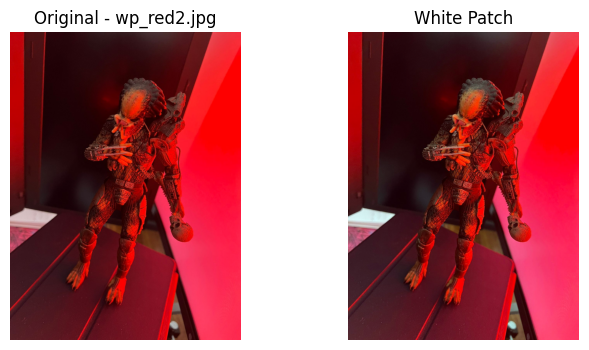

Imagen 5


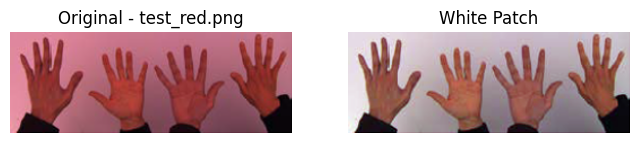

Imagen 6


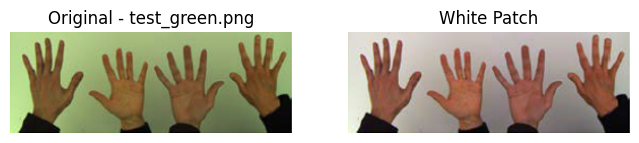

Imagen 7


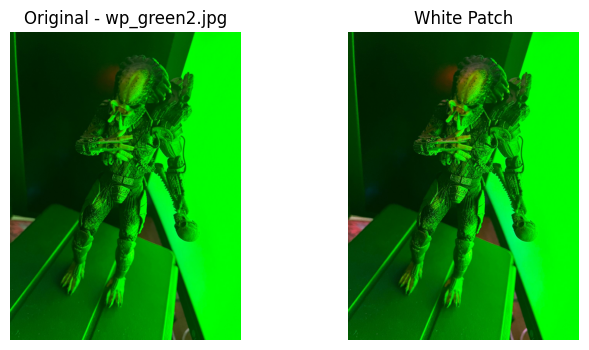

Imagen 8


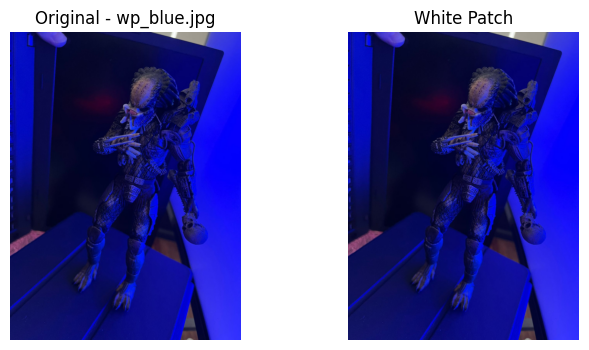

In [21]:
for carpeta in os.listdir(path):
    carpeta_path = os.path.join(path, carpeta)

    if os.path.isdir(carpeta_path):
        for n, archivo in enumerate(os.listdir(carpeta_path)):
          print(f"Imagen {n+1}")
          ruta = os.path.join(carpeta_path, archivo)

          img = cv2.imread(ruta)

          if img is None:
            continue

          img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
          img_wp = white_patch(img)
          img_wp_rgb = cv2.cvtColor(img_wp, cv2.COLOR_BGR2RGB)

          plt.figure(figsize=(8,4))

          plt.subplot(1,2,1)
          plt.title(f"Original - {archivo}")
          plt.imshow(img_rgb)
          plt.axis('off')

          plt.subplot(1,2,2)
          plt.title("White Patch")
          plt.imshow(img_wp_rgb)
          plt.axis('off')

          plt.show()

La principal limitación del algoritmo White Patch es que asume que el píxel más brillante de cada canal corresponde a un blanco real. Sin embargo, esta condición no siempre se cumple en imágenes con iluminación dominante (por ejemplo, luz roja, verde o azul). En estos casos, los valores máximos de cada canal no representan correctamente el color blanco, por lo que el algoritmo realiza una normalización incorrecta. Como consecuencia, los canales se escalan de forma inadecuada y no se logra un balance de color correcto.

Esto se observa en varias imágenes analizadas (principalmente en imágenes 1, 3, 4, 7 y 8), donde la corrección no elimina completamente la dominante de color o incluso introduce colores poco naturales.

Estos resultados evidencian que el desempeño del algoritmo depende fuertemente de las condiciones de iluminación y de la presencia de referencias blancas en la escena, lo que limita su aplicabilidad en entornos controlados.

En contraste, en imágenes donde sí existe un blanco real en la escena (como en el caso de la imagen de las manos), el algoritmo logra una corrección más efectiva, obteniendo colores más naturales.

## Parte 2 - Histograma

Imagenes originales:


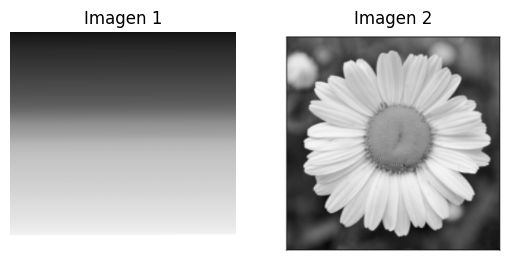

In [3]:
img1 = cv2.imread(f'{path}/img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(f'{path}/img2_tp.png', cv2.IMREAD_GRAYSCALE)

print(f"Imagenes originales:")

plt.subplot(1,2,1)
plt.title("Imagen 1")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Imagen 2")
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.show()

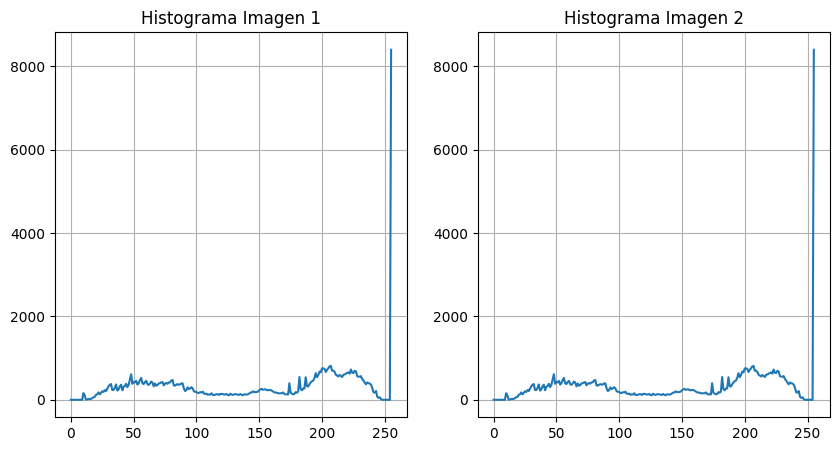

In [4]:
# cv2.calcHist([imagen], [canal], mascara, [cantidad de bins], [rango de valores de intensidad])
# canal: 0 si es escala de grises, o RGB: 0 1 o 2
# Mascara: indica si se usa toda la imagen (None) o solo una region

hist1 = cv2.calcHist([img1], [0], None, [256], [0,256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0,256])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Histograma Imagen 1")
plt.plot(hist1)
plt.grid(True)
plt.subplot(1,2,2)
plt.title("Histograma Imagen 2")
plt.plot(hist2)
plt.grid(True)
plt.show()

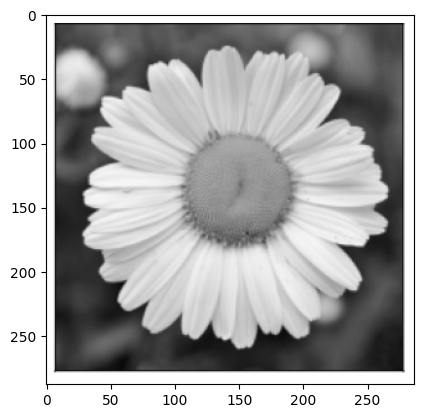

In [6]:
plt.imshow(img2, cmap='gray')

Para la **imagen 1**, el histograma muestra una distribución relativamente uniforme entre los valores 0 y aproximadamente 240, con picos moderados y regulares. Esto es consistente con la presencia de un gradiente suave, donde los niveles de gris aparecen con frecuencias similares. El pico pronunciado en 255 corresponde a píxeles completamente blancos, probablemente ubicados en bordes o zonas de alta intensidad.

Para la **imagen 2**, el histograma es notablemente similar al de la imagen 1, ya que también presenta una distribución amplia junto con un pico en 255. Este comportamiento puede atribuirse a la presencia de zonas muy iluminadas, como los pétalos blancos o el borde de la imagen. Las diferencias se observan principalmente en los valores intermedios, donde algunos picos son levemente más pronunciados, reflejando la presencia de tonos grises claros.

En cuanto al uso de histogramas como features para modelos de clasificación, presentan ventajas como su invariancia a traslaciones y rotaciones, su bajo costo computacional y su capacidad para capturar la distribución global de intensidades. Sin embargo, una limitación importante es que no contienen información espacial ni estructural. Como se observa en este caso, dos imágenes visualmente distintas pueden tener histogramas muy similares, lo que dificultaría su discriminación por parte de un modelo basado únicamente en esta característica.

En conclusión, los histogramas pueden ser útiles como features complementarios, especialmente en tareas donde la diferencia radica en la distribución de intensidades o colores. No obstante, resultan insuficientes por sí solos en problemas de clasificación donde la estructura espacial de la imagen es relevante.